In [1]:
# گام ۱: بارگذاری کتابخانه‌ها
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# مسیر فایل شما
file_path = r"C:\Users\leila.gh\Desktop\employees\burnout,martial conflicts in employees.xlsx"

df = pd.read_excel(file_path, sheet_name='Results', header=0)

print("ابعاد اولیه:", df.shape)
print(df.columns.tolist()[:10])

ابعاد اولیه: (202, 94)
['پاسخنامه', 'شناسه پاسخ دهنده', '1- برایم مشکل است آرام بگیرم.', '2- متوجه شده ام دهانم خشک می شود.', '3- فکر نمی کنم بتوانم هیچ نوع احساس خوبی را تجربه کنم.', '4- تنفس کردن برایم مشکل است.', '5- برایم سخت است در انجام کار پیش قدم شوم.', '6- به موقعیت هایم به طور افراطی واکنش نشان می دهم.', '7- در بدنم احساس لرزش می کنم', '8- احساس می کنم انرژی روانی زیادی مصرف می کنم.']


In [2]:
# گام ۲: حذف سطرهای کاملاً خالی
df = df.dropna(how='all').reset_index(drop=True)
print("ابعاد بعد از حذف سطرهای خالی:", df.shape)

ابعاد بعد از حذف سطرهای خالی: (200, 94)


In [3]:
# گام ۳: تغییر نام ستون‌ها به نام‌های کوتاه
# تعداد ستون‌ها باید ۹۴ باشد: 2 + 21 + 22 + 5 + 42 + 2 = 94
assert len(df.columns) == 94, f"تعداد ستون‌ها {len(df.columns)} است، نه ۹۴!"

new_cols = ['ResponseURL', 'ID']
new_cols += [f'DASS{i}' for i in range(1, 22)]      # ۲۱ سؤال استرس/اضطراب/افسردگی
new_cols += [f'BO{i}' for i in range(1, 23)]        # ۲۲ سؤال فرسودگی شغلی
new_cols += ['Age', 'Gender', 'Education', 'MarriageDuration', 'Children']
new_cols += [f'MC{i}' for i in range(1, 43)]        # ۴۲ سؤال تعارض زناشویی
new_cols += ['StartTime', 'EndTime']

df.columns = new_cols
df.head()

,ResponseURL,ID,DASS1,DASS2,DASS3,DASS4,DASS5,DASS6,DASS7,DASS8,...,MC35,MC36,MC37,MC38,MC39,MC40,MC41,MC42,StartTime,EndTime
0,https://survey.porsline.ir/n/k/oNkjF0mN/hS5K?r...,hS5K,2.0,1.0,3.0,0.0,2.0,1.0,0.0,2.0,...,گاهی,هرگز,گاهی,اکثرا,گاهی,گاهی,گاهی,به ندرت,1401/08/15-15:59:50,1401/08/15-16:05:55
1,https://survey.porsline.ir/n/k/oNkjF0mN/RLWS?r...,RLWS,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,هرگز,به ندرت,هرگز,هرگز,هرگز,هرگز,به ندرت,هرگز,1401/08/14-19:12:44,1401/08/14-19:21:28
2,https://survey.porsline.ir/n/k/oNkjF0mN/6MZ6?r...,6MZ6,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,هرگز,هرگز,هرگز,هرگز,هرگز,به ندرت,به ندرت,به ندرت,1401/08/14-18:25:06,1401/08/14-18:48:16
3,https://survey.porsline.ir/n/k/oNkjF0mN/KtZv?r...,KtZv,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,هرگز,هرگز,هرگز,هرگز,هرگز,گاهی,گاهی,گاهی,1401/08/14-17:40:16,1401/08/14-17:52:42
4,https://survey.porsline.ir/n/k/oNkjF0mN/8fbK?r...,8fbK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,هرگز,هرگز,هرگز,هرگز,هرگز,هرگز,هرگز,هرگز,1401/08/14-17:33:34,1401/08/14-17:46:47


In [4]:
# گام ۴: توابع پاکسازی
def persian_to_english_digits(x):
    if pd.isna(x):
        return x
    x = str(x)
    persian_digits = '۰۱۲۳۴۵۶۷۸۹'
    arabic_digits = '٠١٢٣٤٥٦٧٨٩'
    english_digits = '0123456789'
    trans_table = str.maketrans(persian_digits + arabic_digits, english_digits * 2)
    return x.translate(trans_table)

# ستون‌های عددی DASS و BO
dass_cols = [f'DASS{i}' for i in range(1, 22)]
bo_cols = [f'BO{i}' for i in range(1, 23)]

for col in dass_cols + bo_cols:
    df[col] = df[col].apply(persian_to_english_digits)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ستون‌های تعارض زناشویی
mc_cols = [f'MC{i}' for i in range(1, 43)]

likert_map = {
    'هرگز': 0,
    'به ندرت': 1,
    'گاهی': 2,
    'کاهی': 2,   # اصلاح غلط املایی
    'اکثرا': 3,
    'همیشه': 4
}

for col in mc_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].map(likert_map)

# سن
df['Age'] = df['Age'].apply(persian_to_english_digits)
df['Age'] = df['Age'].astype(str).str.extract(r'(\d+)')[0]
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# جنسیت
df['Gender'] = df['Gender'].astype(str).str.strip()
df['Gender'] = df['Gender'].map({'زن': 1, 'مرد': 0})

# تحصیلات
edu_map = {
    'دیپلم': 1,
    'فوق دیپلم': 2,
    'لیسانس': 3,
    'فوق لیسانس': 4,
    'دکترا': 5
}
df['Education'] = df['Education'].astype(str).str.strip()
df['Education'] = df['Education'].map(edu_map)

# مدت ازدواج
df['MarriageDuration'] = df['MarriageDuration'].apply(persian_to_english_digits)
df['MarriageDuration'] = df['MarriageDuration'].astype(str)
df['MarriageDuration'] = df['MarriageDuration'].str.extract(r'(\d+)')[0]
df['MarriageDuration'] = pd.to_numeric(df['MarriageDuration'], errors='coerce')

# تعداد فرزند
df['Children'] = df['Children'].apply(persian_to_english_digits)
df['Children'] = df['Children'].astype(str)

children_map = {
    'یک': 1, 'دو': 2, 'سه': 3, 'چهار': 4,
    'دوتا': 2, '۰': 0, '۰۱': 1, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5
}
df['Children'] = df['Children'].replace(children_map)
df['Children'] = df['Children'].str.extract(r'(\d+)')[0]
df['Children'] = pd.to_numeric(df['Children'], errors='coerce')

print("پاکسازی انجام شد.")

پاکسازی انجام شد.


In [5]:
# گام ۸: بررسی پایایی (آلفای کرونباخ)
def cronbach_alpha(data):
    data = data.dropna()
    k = data.shape[1]
    variances = data.var(axis=0, ddof=1)
    total_var = data.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - variances.sum() / total_var)

print('آلفای کرونباخ DASS-21:', cronbach_alpha(df[dass_cols]))
print('آلفای کرونباخ فرسودگی:', cronbach_alpha(df[bo_cols]))
print('آلفای کرونباخ تعارض زناشویی:', cronbach_alpha(df[mc_cols]))

آلفای کرونباخ DASS-21: 0.9177441841659858
آلفای کرونباخ فرسودگی: 0.762988207649938
آلفای کرونباخ تعارض زناشویی: 0.8519491773730988


In [6]:
# --- نمره‌گذاری یکپارچه DASS، فرسودگی و تعارض زناشویی ---

# DASS-21
stress_items     = [1, 6, 8, 11, 12, 14, 18]
anxiety_items    = [2, 4, 7, 9, 15, 19, 20]
depression_items = [3, 5, 10, 13, 16, 17, 21]

# فرسودگی شغلی (MBI)
ee_items = [1, 2, 3, 6, 8, 13, 14, 16, 20]   # خستگی هیجانی
dp_items = [5, 10, 11, 15, 22]                # مسخ شخصیت
pa_items = [4, 7, 9, 12, 17, 18, 19, 21]      # موفقیت شخصی

# محاسبه در قالب دیکشنری
scores = {
    'DASS_Stress':       df[[f'DASS{i}' for i in stress_items]].sum(axis=1),
    'DASS_Anxiety':      df[[f'DASS{i}' for i in anxiety_items]].sum(axis=1),
    'DASS_Depression':   df[[f'DASS{i}' for i in depression_items]].sum(axis=1),
    'DASS_Total':        df[dass_cols].sum(axis=1),
    'BO_EE':             df[[f'BO{i}' for i in ee_items]].sum(axis=1),
    'BO_DP':             df[[f'BO{i}' for i in dp_items]].sum(axis=1),
    'BO_PA':             df[[f'BO{i}' for i in pa_items]].apply(lambda x: 7 - x).sum(axis=1),
    'MC_Total':          df[mc_cols].sum(axis=1),
}

# نمره نهایی DASS-21
scores['DASS_Stress_Final']     = scores['DASS_Stress'] * 2
scores['DASS_Anxiety_Final']    = scores['DASS_Anxiety'] * 2
scores['DASS_Depression_Final'] = scores['DASS_Depression'] * 2
scores['DASS_Total_Final']      = scores['DASS_Total'] * 2

# نمره کل فرسودگی
scores['BO_Total'] = scores['BO_EE'] + scores['BO_DP'] + scores['BO_PA']

# ✅ افزودن همه ستون‌ها با یک concat
df = pd.concat([df, pd.DataFrame(scores, index=df.index)], axis=1)

# ✅ defragment نهایی
df = df.copy()

print("نمره‌گذاری انجام شد. ابعاد:", df.shape)

نمره‌گذاری انجام شد. ابعاد: (200, 107)


In [7]:
print("Shape:", df.shape)  # باید (200, 107) باشد نه 133
print("تعداد ستون‌های تکراری:", df.columns.duplicated().sum())  # باید 0 باشد
print("\nستون‌های نمره‌گذاری:")
print(df[['DASS_Stress_Final', 'DASS_Anxiety_Final', 'DASS_Depression_Final',
          'BO_EE', 'BO_DP', 'BO_PA', 'BO_Total', 'MC_Total']].head())

Shape: (200, 107)
تعداد ستون‌های تکراری: 0

ستون‌های نمره‌گذاری:
   DASS_Stress_Final  DASS_Anxiety_Final  DASS_Depression_Final  BO_EE  BO_DP  \
0               24.0                14.0                   32.0   47.0   18.0   
1               14.0                 4.0                    0.0    5.0    3.0   
2                6.0                 0.0                    0.0   10.0    1.0   
3                6.0                 0.0                    0.0   11.0    8.0   
4                2.0                 0.0                    0.0    7.0    0.0   

   BO_PA  BO_Total  MC_Total  
0   30.0      95.0        83  
1   15.0      23.0        13  
2   11.0      22.0        15  
3   18.0      37.0        30  
4    0.0       7.0        11  


In [8]:
desc_cols = ['Age', 'Gender', 'Education', 'MarriageDuration', 'Children',
             'DASS_Stress_Final', 'DASS_Anxiety_Final', 'DASS_Depression_Final',
             'DASS_Total_Final',
             'BO_EE', 'BO_DP', 'BO_PA', 'BO_Total', 'MC_Total']

summary = df[desc_cols].describe().T
summary['missing'] = df[desc_cols].isna().sum()
summary['skew'] = df[desc_cols].skew().round(3)
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,missing,skew
Age,200.0,45.50,8.62,5.0,40.0,45.0,51.00,66.0,0,-0.60
Gender,200.0,0.04,0.21,0.0,0.0,0.0,0.00,1.0,0,4.42
Education,200.0,3.47,0.95,1.0,3.0,4.0,4.00,5.0,0,-1.10
MarriageDuration,199.0,18.93,9.13,1.0,12.0,19.0,26.00,41.0,1,0.19
Children,16.0,0.50,1.75,0.0,0.0,0.0,0.00,7.0,184,3.87
DASS_Stress_Final,200.0,14.02,8.44,2.0,8.0,14.0,18.50,42.0,0,0.74
DASS_Anxiety_Final,200.0,6.33,7.15,0.0,0.0,4.0,10.00,36.0,0,1.54
DASS_Depression_Final,200.0,6.67,7.49,0.0,0.0,4.0,10.00,32.0,0,1.25
DASS_Total_Final,200.0,27.02,20.80,2.0,10.0,21.0,40.00,98.0,0,1.05
BO_EE,200.0,14.16,10.78,0.0,7.0,10.0,18.00,56.0,0,1.53


In [9]:
print("جنسیت:")
print(df['Gender'].value_counts(dropna=False).rename({0:'مرد', 1:'زن'}))

print("\nتحصیلات:")
print(df['Education'].value_counts(dropna=False).sort_index()
      .rename({1:'دیپلم', 2:'فوق دیپلم', 3:'لیسانس', 4:'فوق لیسانس', 5:'دکترا'}))

print("\nتعداد فرزند:")
print(df['Children'].value_counts(dropna=False).sort_index())

جنسیت:
Gender
مرد    191
زن       9
Name: count, dtype: int64

تحصیلات:
Education
دیپلم          15
فوق دیپلم       6
لیسانس         63
فوق لیسانس    102
دکترا          14
Name: count, dtype: int64

تعداد فرزند:
Children
0.0     14
1.0      1
7.0      1
NaN    184
Name: count, dtype: int64


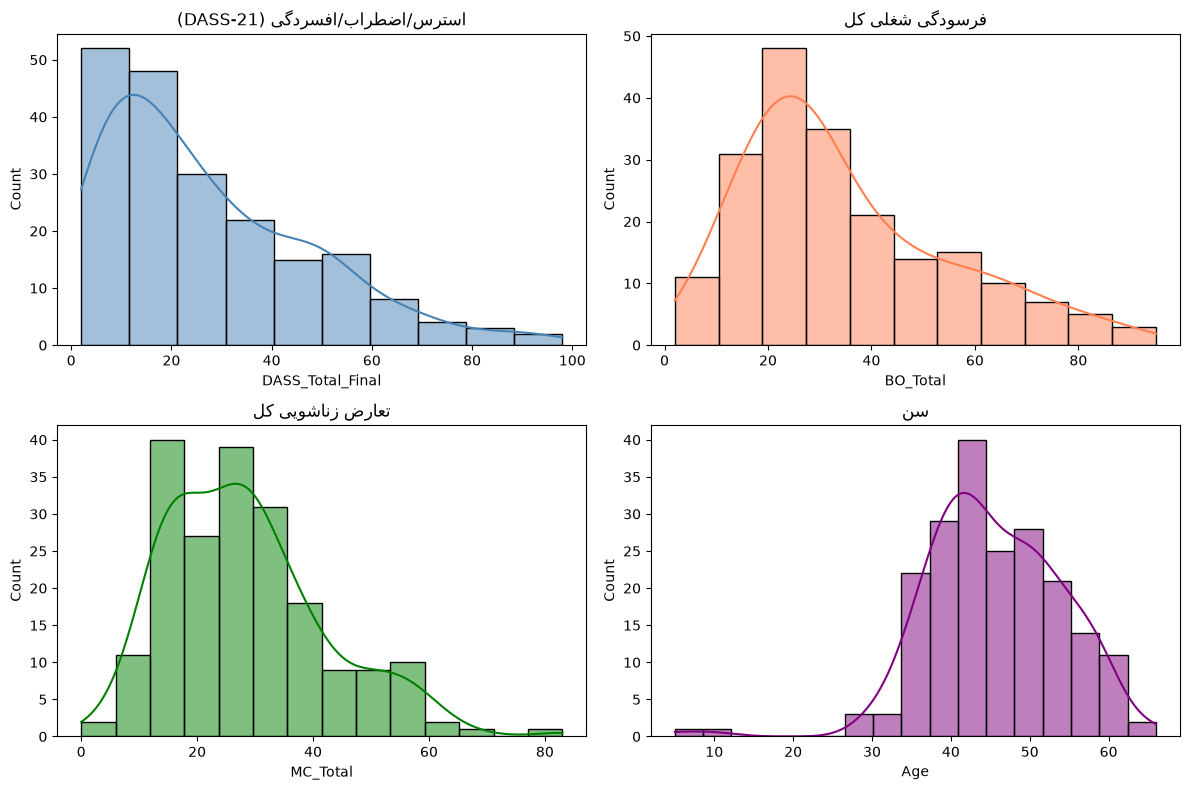

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['DASS_Total_Final'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('استرس/اضطراب/افسردگی (DASS-21)')
sns.histplot(df['BO_Total'], kde=True, ax=axes[0,1], color='coral')
axes[0,1].set_title('فرسودگی شغلی کل')
sns.histplot(df['MC_Total'], kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('تعارض زناشویی کل')
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title('سن')
plt.tight_layout()
plt.show()

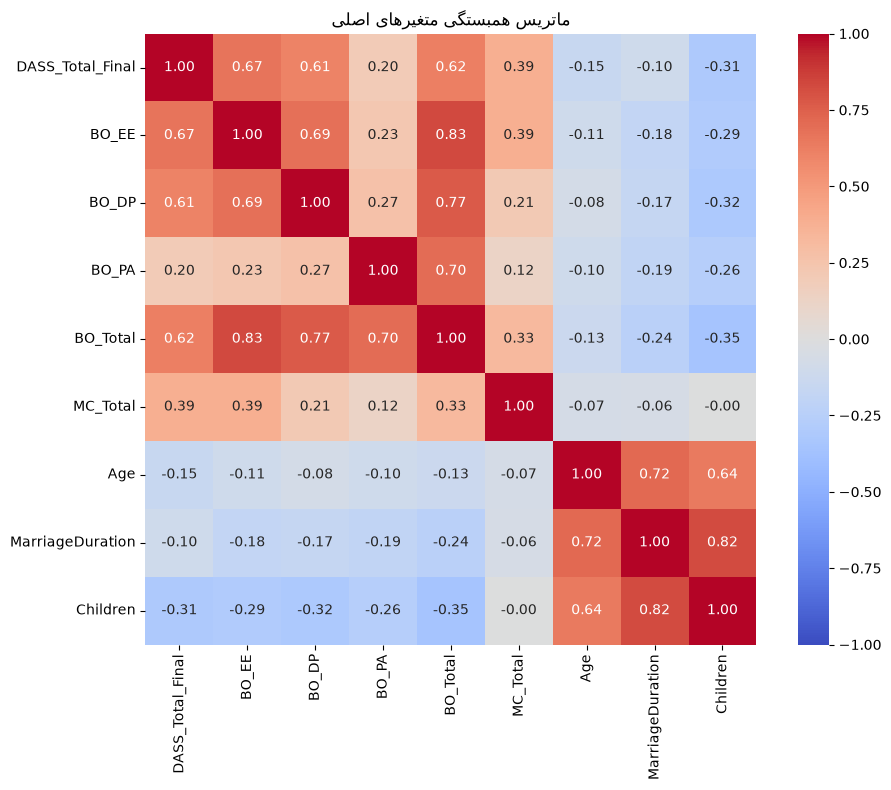

In [11]:
corr_cols = ['DASS_Total_Final', 'BO_EE', 'BO_DP', 'BO_PA', 'BO_Total',
             'MC_Total', 'Age', 'MarriageDuration', 'Children']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', vmin=-1, vmax=1, square=True)
plt.title('ماتریس همبستگی متغیرهای اصلی')
plt.tight_layout()
plt.show()

In [12]:
# نرمالیته (شاپیرو-ویلک)
for c in ['DASS_Total_Final', 'BO_Total', 'MC_Total']:
    s = df[c].dropna()
    stat, p = stats.shapiro(s)
    print(f"Shapiro-Wilk {c}: W={stat:.3f}, p={p:.4f} "
          f"({'نرمال' if p > 0.05 else 'غیرنرمال'})")

Shapiro-Wilk DASS_Total_Final: W=0.904, p=0.0000 (غیرنرمال)
Shapiro-Wilk BO_Total: W=0.925, p=0.0000 (غیرنرمال)
Shapiro-Wilk MC_Total: W=0.949, p=0.0000 (غیرنرمال)


In [13]:
# همبستگی پیرسون + اسپیرمن
pairs = [
    ('DASS_Total_Final', 'BO_Total'),
    ('DASS_Total_Final', 'MC_Total'),
    ('BO_Total', 'MC_Total'),
]
for a, b in pairs:
    r, p_r = stats.pearsonr(df[a], df[b])
    rho, p_s = stats.spearmanr(df[a], df[b])
    print(f"{a} ~ {b}:")
    print(f"  Pearson  r = {r:.3f}, p = {p_r:.4f}")
    print(f"  Spearman ρ = {rho:.3f}, p = {p_s:.4f}\n")

DASS_Total_Final ~ BO_Total:
  Pearson  r = 0.620, p = 0.0000
  Spearman ρ = 0.563, p = 0.0000

DASS_Total_Final ~ MC_Total:
  Pearson  r = 0.386, p = 0.0000
  Spearman ρ = 0.392, p = 0.0000

BO_Total ~ MC_Total:
  Pearson  r = 0.326, p = 0.0000
  Spearman ρ = 0.274, p = 0.0001



In [14]:
for var in ['DASS_Total_Final', 'BO_Total', 'MC_Total']:
    male = df.loc[df['Gender'] == 0, var].dropna()
    female = df.loc[df['Gender'] == 1, var].dropna()

    # نرمالیته هر گروه
    _, p_m = stats.shapiro(male)
    _, p_f = stats.shapiro(female)

    if p_m > 0.05 and p_f > 0.05:
        t, p = stats.ttest_ind(male, female, equal_var=False)
        print(f"{var}: t-test  t={t:.3f}, p={p:.4f}")
    else:
        u, p = stats.mannwhitneyu(male, female)
        print(f"{var}: Mann-Whitney U={u:.1f}, p={p:.4f}")

    print(f"  میانگین مرد={male.mean():.2f} | زن={female.mean():.2f}\n")

DASS_Total_Final: Mann-Whitney U=572.0, p=0.0904
  میانگین مرد=26.35 | زن=41.33

BO_Total: Mann-Whitney U=546.5, p=0.0654
  میانگین مرد=34.13 | زن=52.00

MC_Total: Mann-Whitney U=684.0, p=0.3021
  میانگین مرد=27.99 | زن=34.78



In [15]:
import statsmodels.api as sm

X = df[['DASS_Total_Final', 'MC_Total', 'Age', 'MarriageDuration']].dropna()
y = df.loc[X.index, 'BO_Total']

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               BO_Total   R-squared:                       0.440
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     38.08
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           1.69e-23
Time:                        18:11:25   Log-Likelihood:                -822.78
No. Observations:                 199   AIC:                             1656.
Df Residuals:                     194   BIC:                             1672.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.9515      7.053  

In [16]:
output_path = r"C:\Users\leila.gh\Desktop\employees\cleaned_data.xlsx"
df.to_excel(output_path, index=False)
print("ذخیره شد:", output_path)

ذخیره شد: C:\Users\leila.gh\Desktop\employees\cleaned_data.xlsx


In [17]:
print(df[df['Age'] < 18][['ID', 'Age', 'Gender', 'Education']])

       ID  Age  Gender  Education
142  5Rut    5       0          4
162  B3r5   10       0          5


In [18]:
# حذف رکوردهای با سن مشکوک (خطای ورود داده)
invalid_age_ids = ['5Rut', 'B3r5']
before = len(df)
df = df[~df['ID'].isin(invalid_age_ids)].reset_index(drop=True)
after = len(df)
print(f"حذف {before - after} رکورد با سن مشکوک: {invalid_age_ids}")

حذف 2 رکورد با سن مشکوک: ['5Rut', 'B3r5']


In [19]:
# آمار توصیفی نهایی
summary = df[desc_cols].describe().T
summary['missing'] = df[desc_cols].isna().sum()
summary['skew'] = df[desc_cols].skew().round(3)
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,missing,skew
Age,198.0,45.89,7.75,30.0,40.0,45.0,51.00,66.0,0,0.23
Gender,198.0,0.05,0.21,0.0,0.0,0.0,0.00,1.0,0,4.40
Education,198.0,3.46,0.95,1.0,3.0,4.0,4.00,5.0,0,-1.11
MarriageDuration,197.0,18.81,9.09,1.0,12.0,19.0,26.00,41.0,1,0.21
Children,16.0,0.50,1.75,0.0,0.0,0.0,0.00,7.0,182,3.87
DASS_Stress_Final,198.0,13.98,8.47,2.0,8.0,14.0,18.00,42.0,0,0.75
DASS_Anxiety_Final,198.0,6.31,7.18,0.0,0.0,4.0,10.00,36.0,0,1.55
DASS_Depression_Final,198.0,6.62,7.51,0.0,0.0,4.0,10.00,32.0,0,1.27
DASS_Total_Final,198.0,26.91,20.87,2.0,10.0,20.0,40.00,98.0,0,1.06
BO_EE,198.0,14.20,10.83,0.0,7.0,10.0,18.00,56.0,0,1.52


In [20]:
# رگرسیون نهایی
import statsmodels.api as sm

X = df[['DASS_Total_Final', 'MC_Total', 'Age', 'MarriageDuration']].dropna()
y = df.loc[X.index, 'BO_Total']
model = sm.OLS(y, sm.add_constant(X)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               BO_Total   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     37.31
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           4.54e-23
Time:                        18:11:26   Log-Likelihood:                -815.30
No. Observations:                 197   AIC:                             1641.
Df Residuals:                     192   BIC:                             1657.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.7802     10.102  